In [105]:
import pandas as pd
import matplotlib.pyplot as plt

In [106]:
df = pd.read_excel("../data/processed/oil_well_clean.xlsx")
df.head()

,date,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
0,2013-01-01,49,70,13055,21,29,24,1819,214
1,2013-01-02,49,70,13055,21,29,24,1836,214
2,2013-01-03,49,70,13055,21,29,24,1788,214
3,2013-01-04,49,70,13055,21,29,24,1789,214
4,2013-01-05,44,70,11768,26,36,24,1825,214


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2939 entries, 0 to 2938
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                2939 non-null   datetime64[ns]
 1   oil_volume          2939 non-null   int64         
 2   liquid_volume       2939 non-null   int64         
 3   gas_volume          2939 non-null   int64         
 4   water_volume        2939 non-null   int64         
 5   water_cut           2939 non-null   int64         
 6   working_hours       2939 non-null   int64         
 7   dynamic_level       2939 non-null   int64         
 8   reservoir_pressure  2939 non-null   int64         
dtypes: datetime64[ns](1), int64(8)
memory usage: 206.8 KB


In [108]:
df.dtypes

date                  datetime64[ns]
oil_volume                     int64
liquid_volume                  int64
gas_volume                     int64
water_volume                   int64
water_cut                      int64
working_hours                  int64
dynamic_level                  int64
reservoir_pressure             int64
dtype: object

In [109]:
df["date"].min(), df["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2021-01-18 00:00:00'))

In [110]:
df = df.sort_values("date")

In [111]:
df["date"].duplicated().sum()

np.int64(0)

In [112]:
df["date"].diff().value_counts()

date
1 days    2937
2 days       1
Name: count, dtype: int64

In [113]:
df[df["date"].diff() > pd.Timedelta(days=1)]

,date,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
880,2015-06-01,23,66,6256,43,64,20,1948,180


In [114]:
df[(df["date"] >= "2015-05-29") & (df["date"] <= "2015-06-02")]

,date,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
878,2015-05-29,24,68,6433,44,64,20,1951,180
879,2015-05-30,26,74,6987,48,64,22,1938,180
880,2015-06-01,23,66,6256,43,64,20,1948,180
881,2015-06-02,26,74,6987,48,64,22,1932,180


In [115]:
df = df.set_index("date")

In [116]:
(df["oil_volume"] > df["liquid_volume"]).sum()

np.int64(0)

In [117]:
df.head()

,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
date,,,,,,,,
2013-01-01,49,70,13055,21,29,24,1819,214
2013-01-02,49,70,13055,21,29,24,1836,214
2013-01-03,49,70,13055,21,29,24,1788,214
2013-01-04,49,70,13055,21,29,24,1789,214
2013-01-05,44,70,11768,26,36,24,1825,214


In [118]:
df = df.asfreq("D")

df = df.interpolate()

In [119]:
df.isna().sum()

oil_volume            0
liquid_volume         0
gas_volume            0
water_volume          0
water_cut             0
working_hours         0
dynamic_level         0
reservoir_pressure    0
dtype: int64

In [120]:
df.loc["2015-05-28":"2015-06-05"]

,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
date,,,,,,,,
2015-05-28,24.0,69.0,6564.0,45.0,64.0,20.0,1942.0,180.0
2015-05-29,24.0,68.0,6433.0,44.0,64.0,20.0,1951.0,180.0
2015-05-30,26.0,74.0,6987.0,48.0,64.0,22.0,1938.0,180.0
2015-05-31,24.5,70.0,6621.5,45.5,64.0,21.0,1943.0,180.0
2015-06-01,23.0,66.0,6256.0,43.0,64.0,20.0,1948.0,180.0
2015-06-02,26.0,74.0,6987.0,48.0,64.0,22.0,1932.0,180.0
2015-06-03,22.0,63.0,5970.0,41.0,64.0,19.0,1948.0,180.0
2015-06-04,28.0,81.0,7622.0,52.0,64.0,24.0,1939.0,180.0
2015-06-05,19.0,55.0,5176.0,35.0,64.0,16.0,1887.0,180.0


In [121]:
df.isna().sum()

oil_volume            0
liquid_volume         0
gas_volume            0
water_volume          0
water_cut             0
working_hours         0
dynamic_level         0
reservoir_pressure    0
dtype: int64

In [122]:
df.describe()

,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
count,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000
mean,17.626701,59.467687,4730.789626,41.830102,70.692517,22.344218,1930.387755,157.026871
std,9.688208,18.631944,2598.680466,13.054579,9.533381,3.039137,114.524500,32.914279
min,0.000000,12.000000,4.000000,9.000000,29.000000,7.000000,1529.000000,100.000000
25%,11.000000,50.000000,3042.250000,33.000000,69.000000,22.000000,1855.000000,129.000000
50%,15.000000,58.000000,3910.500000,43.000000,73.000000,24.000000,1890.000000,157.000000
75%,22.000000,74.000000,5844.000000,50.000000,76.000000,24.000000,2008.000000,185.250000
max,49.000000,113.000000,13113.000000,99.000000,100.000000,24.000000,2137.000000,214.000000


<Figure size 640x480 with 0 Axes>

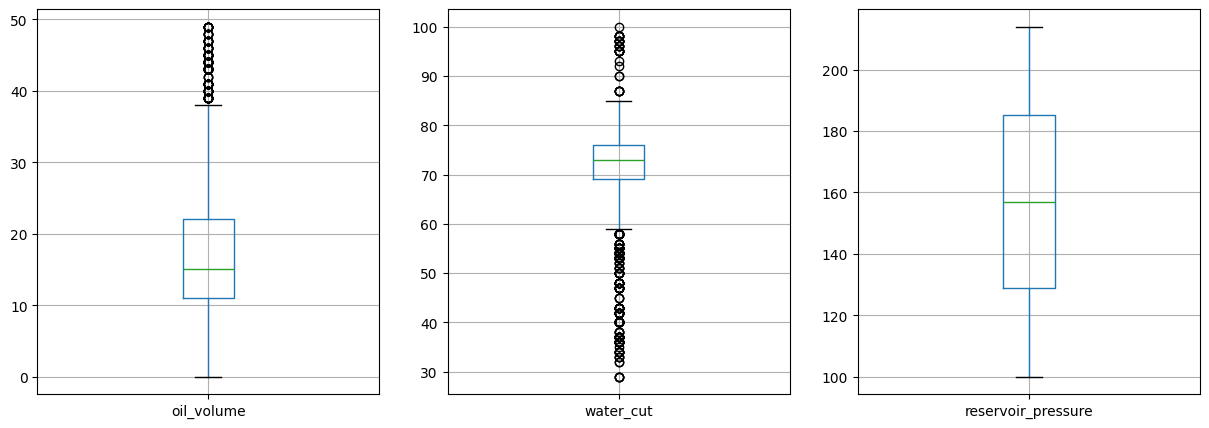

In [143]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
df.boxplot(column="oil_volume", ax=axes[0])
df.boxplot(column="water_cut", ax=axes[1])
df.boxplot(column="reservoir_pressure", ax=axes[2])

plt.savefig("../outputs/figures/boxplots.png")
plt.show()

In [131]:
(df["oil_volume"] + df["water_volume"] - df["liquid_volume"]).abs().max()

np.float64(1.0)

In [142]:
df.to_excel("../data/processed/oil_well_clean.xlsx", index=False)